# Bike Sharing Demand：時間帯・曜日・季節・天候

run_id: `v020-exp-34`。競技と同じ公開CSVを取得し、観測された関連を分析する。因果効果を推定する研究ではない。

In [1]:
from pathlib import Path
import os, sys, io, json, hashlib, zipfile, warnings, contextlib, inspect
from datetime import datetime, timezone
from dataclasses import asdict
REPO = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import nbformat
from ai_data_scientist import project_manager, lifecycle, language_router, ingestion, cleaning, eda
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity
from ai_data_scientist import visualization, notebook_audit, insight_engine
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-34-bike-sharing')
RUN_ID = 'v020-exp-34'
lifecycle.register_run(RUN_ID, handle.notebook_path)
lifecycle.mark_write_start(RUN_ID)
try:
    project_manager.ensure_notebook(handle)
    DATA_DIR = project_manager.ensure_data_dir(handle)
finally:
    lifecycle.mark_write_end(RUN_ID)
LANGUAGE = language_router.detect_language('自転車需要を分析してください')
phase_log = []
@contextlib.contextmanager
def phase(name, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('キャンセル要求を受信')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed'})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'time': datetime.now(timezone.utc).isoformat()})
print('初期化', LANGUAGE, RUN_ID)
print('図表・モデル・APIの実行はJupyter MCP、コードの著者書込みはenqueue_write。MCPは実行出力を保存する。')


初期化 ja v020-exp-34
図表・モデル・APIの実行はJupyter MCP、コードの著者書込みはenqueue_write。MCPは実行出力を保存する。


In [2]:
api_log = []
api = None
candidates = []
with phase('Kaggle認証・公開データ検索'):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        api_log.append({'step': 'authenticate', 'status': 'ok'})
        for query in ['bike sharing demand', 'bike-sharing-demand']:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query, page=1)
            rows = [{'ref': d.ref, 'title': d.title} for d in found]
            candidates.extend(rows)
            api_log.append({'step': 'dataset_list', 'search': query, 'results': rows})
    except Exception as exc:
        api_log.append({'step': 'Kaggle API', 'status': 'failed', 'exception_type': type(exc).__name__})
        print('Kaggle API失敗：例外の本文は認証情報保護のため非表示。型:', type(exc).__name__)
print(json.dumps(api_log, ensure_ascii=False, indent=2))
if api is not None:
    print('dataset_list_files signature:', inspect.signature(api.dataset_list_files))
    print('dataset_download_file signature:', inspect.signature(api.dataset_download_file))


[
  {
    "step": "authenticate",
    "status": "ok"
  },
  {
    "step": "dataset_list",
    "search": "bike sharing demand",
    "results": [
      {
        "ref": "saurabhshahane/seoul-bike-sharing-demand-prediction",
        "title": "Seoul Bike Sharing Demand Prediction"
      },
      {
        "ref": "joebeachcapital/seoul-bike-sharing",
        "title": "Seoul Bike Sharing Demand Prediction "
      },
      {
        "ref": "lakshmi25npathi/bike-sharing-dataset",
        "title": "Bike Sharing Dataset"
      },
      {
        "ref": "taweilo/capital-bikeshare-dataset-202005202408",
        "title": "Capital bikeshare dataset 2020/05~2024/08"
      },
      {
        "ref": "yasserh/bike-sharing-dataset",
        "title": "Bike Sharing Dataset"
      },
      {
        "ref": "abdullapathan/bikesharingdemand",
        "title": "bike-sharing-demand"
      },
      {
        "ref": "m0hand/bike-sharing-demand-prediction",
        "title": "Bike sharing demand prediction🐝🚴🏻‍♂️‏"


In [3]:
selected_slug = 'abdullapathan/bikesharingdemand'
file_listing = []
with phase('Kaggleファイル一覧'):
    if api is None:
        print('認証または検索が失敗。取得失敗として後続でwhite-paperを確認する。')
    else:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                response = api.dataset_list_files(selected_slug)
            file_listing = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in response.files]
            api_log.append({'step': 'dataset_list_files', 'slug': selected_slug, 'files': file_listing})
            print(json.dumps(api_log[-1], ensure_ascii=False, indent=2))
        except Exception as exc:
            api_log.append({'step': 'dataset_list_files', 'slug': selected_slug, 'exception_type': type(exc).__name__})
            print('ファイル一覧取得失敗:', type(exc).__name__)


{
  "step": "dataset_list_files",
  "slug": "abdullapathan/bikesharingdemand",
  "files": [
    {
      "name": "sampleSubmission.csv",
      "bytes": 142861
    },
    {
      "name": "test.csv",
      "bytes": 323856
    },
    {
      "name": "train.csv",
      "bytes": 648353
    }
  ]
}


## 取得・データ定義・分析前提

同名のSeoul/Divvyデータは対象外。競技名に対応する公開ミラーを選択し、列・件数・期間を照合する。バイト単位の競技オリジナル照合までは行っていない。

In [4]:
provenance = []
metadata_text = ''
acquisition_ok = False
with phase('Kaggle CSV取得とSHA-256'):
    if api is not None and {'train.csv', 'test.csv'} <= {f['name'] for f in file_listing}:
        try:
            for name in ['train.csv', 'test.csv']:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    api.dataset_download_file(selected_slug, name, path=str(DATA_DIR), force=True, quiet=True)
                path = DATA_DIR / name
                if not path.exists():
                    archived = DATA_DIR / (name + '.zip')
                    if not archived.exists():
                        raise FileNotFoundError('API応答後のCSV/ZIPが存在しない')
                    with zipfile.ZipFile(archived) as archive:
                        matching = [n for n in archive.namelist() if Path(n).name == name]
                        if len(matching) != 1:
                            raise ValueError('ZIP内の対応ファイルが一意でない')
                        path.write_bytes(archive.read(matching[0]))
                provenance.append({'owner_dataset_slug': selected_slug, 'file_name': name,
                    'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                    'sha256': hashlib.sha256(path.read_bytes()).hexdigest(), 'bytes': path.stat().st_size,
                    'url': 'https://www.kaggle.com/datasets/' + selected_slug})
            acquisition_ok = True
        except Exception as exc:
            api_log.append({'step': 'dataset_download_file', 'status': 'failed', 'exception_type': type(exc).__name__})
            print('CSV取得失敗:', type(exc).__name__)
    if not acquisition_ok:
        paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        print('指定white-paper確認:', paper.exists())
        if paper.exists():
            text = paper.read_text(encoding='utf-8')
            lines = text.splitlines()
            relevant = [i for i, line in enumerate(lines) if 'bike-sharing-demand' in line.lower() or 'bike sharing demand' in line.lower()]
            for i in relevant:
                print('\n'.join(lines[max(0,i-3):i+8]))
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('取得失敗。white-paperに明記された同一データCSVの確認前に代替データを採用しない。')
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_metadata(selected_slug, path=str(DATA_DIR))
            meta = json.loads((DATA_DIR / 'dataset-metadata.json').read_text(encoding='utf-8'))
        metadata_text = meta.get('description', '') or ''
        print('公開データ記述:', metadata_text[:14000] if metadata_text else '空。定義はinferred/unknownで記録する。')
    except Exception as exc:
        print('データ辞書取得不可:', type(exc).__name__, '意味の定義は未検証として記録する')
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(DATA_DIR / 'train.csv')), row_limit=20000)
    df = loaded.dataframe
    test = ingestion.ingest(ingestion.SourceSpec('csv', str(DATA_DIR / 'test.csv')), row_limit=20000).dataframe
    expected = ['datetime','season','holiday','workingday','weather','temp','atemp','humidity','windspeed','casual','registered','count']
    assert list(df.columns) == expected, '競技の列定義と異なる'
    assert len(df) == 10886 and len(test) == 6493, '競技の既知の標本サイズと異なる'
    df['datetime'] = pd.to_datetime(df['datetime'], errors='raise')
    test['datetime'] = pd.to_datetime(test['datetime'], errors='raise')
    df = df.sort_values('datetime').reset_index(drop=True)
    test = test.sort_values('datetime').reset_index(drop=True)
    assert df['datetime'].min() == pd.Timestamp('2011-01-01 00:00:00')
    assert df['datetime'].max() == pd.Timestamp('2012-12-19 23:00:00')
    print('競技対応チェック:', len(df), len(test), '列・期間・毎月19日までのラベルありデータを検証')
    display(df.head())


公開データ記述: 空。定義はinferred/unknownで記録する。
[
  {
    "owner_dataset_slug": "abdullapathan/bikesharingdemand",
    "file_name": "train.csv",
    "retrieved_at_utc": "2026-10-01T21:56:31.877542+00:00",
    "sha256": "0cf70c35eeb6405a40cc9e124854e2da901fa88fe7374a75d141e7401bf4c857",
    "bytes": 648353,
    "url": "https://www.kaggle.com/datasets/abdullapathan/bikesharingdemand"
  },
  {
    "owner_dataset_slug": "abdullapathan/bikesharingdemand",
    "file_name": "test.csv",
    "retrieved_at_utc": "2026-10-01T21:56:33.226911+00:00",
    "sha256": "3f1d0ebb197ba9b9a79280b30912093ce18959fac6e1931691092cda449eb63e",
    "bytes": 323856,
    "url": "https://www.kaggle.com/datasets/abdullapathan/bikesharingdemand"
  }
]
競技対応チェック: 10886 6493 列・期間・毎月19日までのラベルありデータを検証


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
with phase('データ定義・前提・意味的検査'):
    F = data_definition.FieldValue
    definition = data_definition.build_manifest(
        source={'competition': F('https://www.kaggle.com/competitions/bike-sharing-demand', 'reported', 'ユーザー指定'),
                'identity': F(provenance, 'verified', 'SDK取得とSHA-256'),
                'license': F(None, 'unknown', '再配布許諾を独立確認していない')},
        dataset_scope={'period': F([str(df.datetime.min()), str(df.datetime.max())], 'verified', 'CSV'),
                       'city': F('Washington DC / Capital Bikeshare', 'inferred', '競技名と辞書の対応。独立原票照合なし'),
                       'sampling': F('trainは毎月1〜19日、testは20日以降。欠測時刻あり', 'verified', 'CSV実測'),
                       'timezone': F(None, 'unknown', 'datetimeにオフセットなし')},
        variables={
            'datetime': {'definition': F('時間別タイムスタンプ', 'inferred', '名前と時刻差'), 'unit': F('1時間', 'verified', '時刻差')},
            'count': {'definition': F('時間別の総貸出件数（固有利用者数ではない）', 'inferred', '競技スキーマ、casual+registered一致'), 'unit': F('件/時間', 'inferred')},
            'season': {'mapping': F({1:'spring',2:'summer',3:'fall',4:'winter'}, 'inferred', '競技辞書の一般的表記。暦月との一致は別途検査')},
            'weather': {'mapping': F({1:'clear/partly cloudy',2:'mist/cloudy',3:'light rain/snow',4:'heavy rain/snow/fog'}, 'inferred', '競技辞書の一般的表記、外部定義の実取得がない場合は未検証')},
            'workingday': {'definition': F('平日かつ非祝日=1', 'inferred', '曜日・holidayと照合')},
            'holiday': {'definition': F('祝日=1', 'inferred', '列名。祝日暦との照合なし')},
            'temp': {'unit': F('摂氏', 'inferred', '競技のスキーマと値域')},
            'atemp': {'unit': F('体感温度・摂氏', 'inferred')},
            'humidity': {'unit': F('%', 'inferred')},
            'windspeed': {'unit': F('未確認', 'unknown')},
            'casual': {'definition': F('非登録利用の貸出件数', 'inferred')},
            'registered': {'definition': F('登録利用の貸出件数', 'inferred')}})
    print('データ定義manifest:', json.dumps(asdict(definition), ensure_ascii=False, default=str, indent=2))
    print('unknown:', [(k, asdict(v)) for k,v in definition.unresolved_fields()])
    print('inferred一覧:', [f'{name}.{key}' for name,fields in definition.variables.items() for key,value in fields.items() if value.status=='inferred'])
    print('inferredも検証済みとは扱わない。季節はコードで報告し暦月も併記する。')
    schema = {c: {'not_null': True} for c in df.columns}
    for c in ['count','casual','registered','windspeed']:
        schema[c]['min'] = 0
    schema.update({'datetime': {'not_null':True,'unique':True},'season':{'allowed':[1,2,3,4],'not_null':True},
                   'weather':{'allowed':[1,2,3,4],'not_null':True},'holiday':{'allowed':[0,1],'not_null':True},
                   'workingday':{'allowed':[0,1],'not_null':True}, 'humidity':{'min':0,'max':100,'not_null':True}})
    anomalies = data_quality.detect_anomalies(df, schema)
    print('意味的制約違反:', [asdict(a) for a in anomalies])
    clean = cleaning.clean_dataset(df, operation='drop_duplicates')
    print('clean_dataset戻り値:', clean if not hasattr(clean, 'dataframe') else {k:v for k,v in vars(clean).items() if k!='dataframe'})
    for name, obj in [('cleaning',clean),('eda',eda.explore(df))]:
        if name == 'eda':
            print('EDA:', str(obj)[:4000])
    df['hour'] = df.datetime.dt.hour
    df['dow'] = df.datetime.dt.dayofweek
    df['month'] = df.datetime.dt.month
    df['year'] = df.datetime.dt.year
    df['date'] = df.datetime.dt.normalize()
    df['ym'] = df.datetime.dt.to_period('M').astype(str)
    df['trend'] = (df.datetime - pd.Timestamp('2011-01-01')).dt.total_seconds()/86400
    total_identity_bad = int((df['count'] != df.casual+df.registered).sum())
    integer_bad = int((df[['count','casual','registered']] % 1 != 0).any(axis=1).sum())
    work_mismatch = int((df.workingday != ((df.dow < 5) & (df.holiday == 0)).astype(int)).sum())
    combined = pd.concat([df[['datetime']], test[['datetime']]]).sort_values('datetime')
    full_hours = pd.date_range('2011-01-01', '2012-12-31 23:00:00', freq='h')
    missing_hours = full_hours.difference(combined.datetime)
    quality_summary = {'rows':len(df), 'test_rows':len(test),'count_identity_violations':total_identity_bad,
        'noninteger_demand':integer_bad, 'workingday_mismatches':work_mismatch,
        'train_max_day':int(df.datetime.dt.day.max()),'test_min_day':int(test.datetime.dt.day.min()),
        'overlap':len(set(df.datetime)&set(test.datetime)), 'missing_hours_train_and_test':len(missing_hours),
        'zero_humidity':int((df.humidity==0).sum()),'zero_windspeed':int((df.windspeed==0).sum()),
        'demand_mean':float(df['count'].mean()),'demand_median':float(df['count'].median()),
        'demand_variance':float(df['count'].var()),'demand_skew':float(df['count'].skew()),
        'demand_max':int(df['count'].max()), 'zero_count':int((df['count']==0).sum())}
    print('品質と分布:',json.dumps(quality_summary, ensure_ascii=False, indent=2))
    display(pd.crosstab(df.month, df.season))
    display(df.groupby('weather')['count'].agg(['size','mean','median','std']))
    display(pd.Series(missing_hours.hour).value_counts().sort_index().rename('missing_by_hour'))
    assert not anomalies and total_identity_bad == 0 and integer_bad == 0 and work_mismatch == 0
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'outcome':'count','population':'2011-2012のラベルあり時間','causality':'観察的関連'},
        causal_scope='associational',
        assumptions=(
            analysis_assumptions.Assumption('no_leakage','予測にcasual/registeredを使用せず過去期間だけで学習', 'tested', conclusion_critical=True),
            analysis_assumptions.Assumption('missing_hours','未観測時間をゼロ需要に置換しない', 'verified'),
            analysis_assumptions.Assumption('full_month','1〜19日の関連が20日以降にも同様', 'assumed', impact_if_false='月末需要へ移植不可', conclusion_critical=True),
            analysis_assumptions.Assumption('future_stationarity','2013年以降も需要水準・構造が安定', 'assumed', impact_if_false='長期予測不可', conclusion_critical=True),
            analysis_assumptions.Assumption('weather_forecast','予測時の天候・気温を真値で利用できる', 'assumed', impact_if_false='実運用の誤差は検証より大きい', conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    print('分析前提manifest:',json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    print('全前提指摘:', [asdict(f) for f in assumption_findings])
    print('独立参照データ検証は適用不可：test.csvは同じ採集元でラベルなし。独立データでないためvalidate_anomalies/compare_datasets未使用。')


データ定義manifest: {
  "source": {
    "competition": {
      "value": "https://www.kaggle.com/competitions/bike-sharing-demand",
      "status": "reported",
      "source": "ユーザー指定"
    },
    "identity": {
      "value": [
        {
          "owner_dataset_slug": "abdullapathan/bikesharingdemand",
          "file_name": "train.csv",
          "retrieved_at_utc": "2026-10-01T21:56:31.877542+00:00",
          "sha256": "0cf70c35eeb6405a40cc9e124854e2da901fa88fe7374a75d141e7401bf4c857",
          "bytes": 648353,
          "url": "https://www.kaggle.com/datasets/abdullapathan/bikesharingdemand"
        },
        {
          "owner_dataset_slug": "abdullapathan/bikesharingdemand",
          "file_name": "test.csv",
          "retrieved_at_utc": "2026-10-01T21:56:33.226911+00:00",
          "sha256": "3f1d0ebb197ba9b9a79280b30912093ce18959fac6e1931691092cda449eb63e",
          "bytes": 323856,
          "url": "https://www.kaggle.com/datasets/abdullapathan/bikesharingdemand"
        }
     

season,1,2,3,4
month,,,,
1,884,0,0,0
2,901,0,0,0
3,901,0,0,0
4,0,909,0,0
5,0,912,0,0
6,0,912,0,0
7,0,0,912,0
8,0,0,912,0
9,0,0,909,0


,size,mean,median,std
weather,,,,
1,7192,205.236791,161.0,187.959566
2,2834,178.955540,134.0,168.366413
3,859,118.846333,71.0,138.581297
4,1,164.000000,164.0,NaN


0      5
1      7
2     16
3     34
4     34
5     14
6      6
7      4
8      4
9      4
10     4
11     4
12     3
13     2
14     2
15     2
16     1
17     1
18     3
19     3
20     3
21     3
22     3
23     3
Name: missing_by_hour, dtype: int64

## 初回分析

右裾の長い需要を平均・中央値・log1p分布で確認する。時間帯区間は週ブロックbootstrap（600回、seed=34）。ランダム分割やゼロ補完を避け、2012年Q1〜Q3の拡大型検証だけでモデルを選び、Q4を固定holdoutとする。季節名は未検証なのでコードと暦月で示す。

区間は週単位の標本変動を表す。観測日選択の偏り・未観測年・因果交絡は区間に含まれない。


,count
count,10886.000000
mean,191.574132
std,181.144454
min,1.000000
10%,9.000000
50%,145.000000
90%,452.000000
95%,563.750000
99%,774.150000
max,977.000000


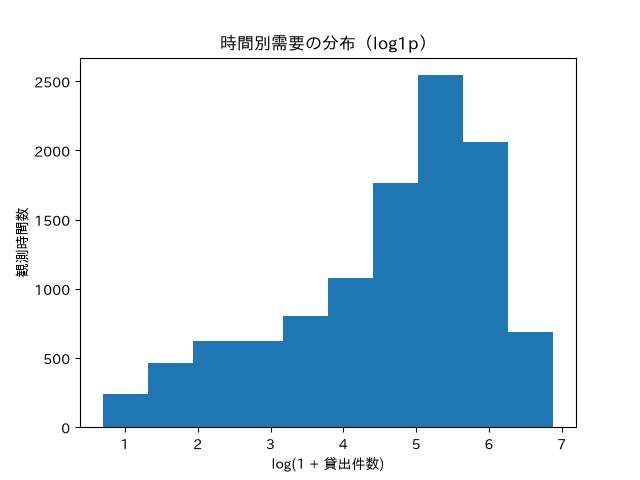

,workingday,hour,size,mean,median
0,0,0,145,94.489655,96.0
1,0,1,145,71.910345,73.0
2,0,2,143,53.748252,56.0
3,0,3,144,25.534722,26.0
4,0,4,145,8.544828,8.0
5,0,5,142,9.373239,8.0
6,0,6,145,19.993103,16.0
7,0,7,145,47.268966,40.0
8,0,8,145,112.255172,98.0
9,0,9,145,177.924138,179.0


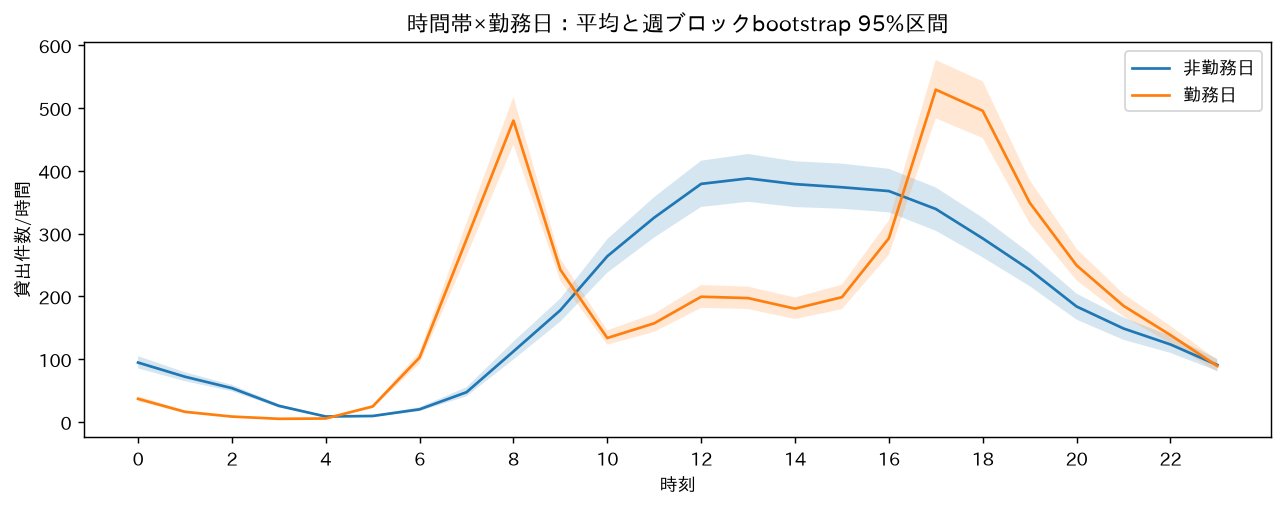

,size,mean,median
dow,,,
0,1551,190.390716,146.0
1,1539,189.723847,146.0
2,1551,188.411348,136.0
3,1553,197.296201,155.0
4,1529,197.844343,167.0
5,1584,196.665404,141.5
6,1579,180.839772,119.0


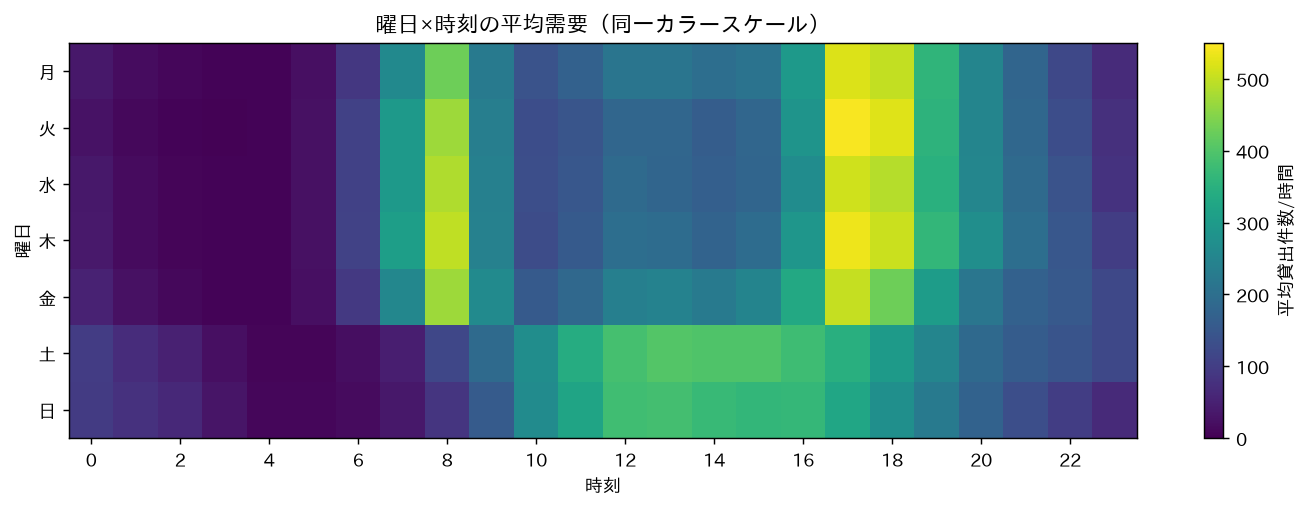

,size,mean,median
ym,,,
2011-01,431,54.645012,47.0
2011-02,446,73.641256,59.0
2011-03,446,86.849776,72.0
2011-04,455,111.026374,84.0
2011-05,456,174.809211,154.0
2011-06,456,196.877193,172.0
2011-07,456,203.614035,173.0
2011-08,456,182.666667,159.0
2011-09,453,174.622517,147.0


size        mean  median
year season                          
2011 1       1323   71.905518    57.0
     2       1367  160.940746   136.0
     3       1365  186.994872   163.0
     4       1367  154.787125   128.0
2012 1       1363  159.476889   120.0
     2       1366  269.601757   239.0
     3       1368  281.735380   251.0
     4       1367  243.189466   211.0

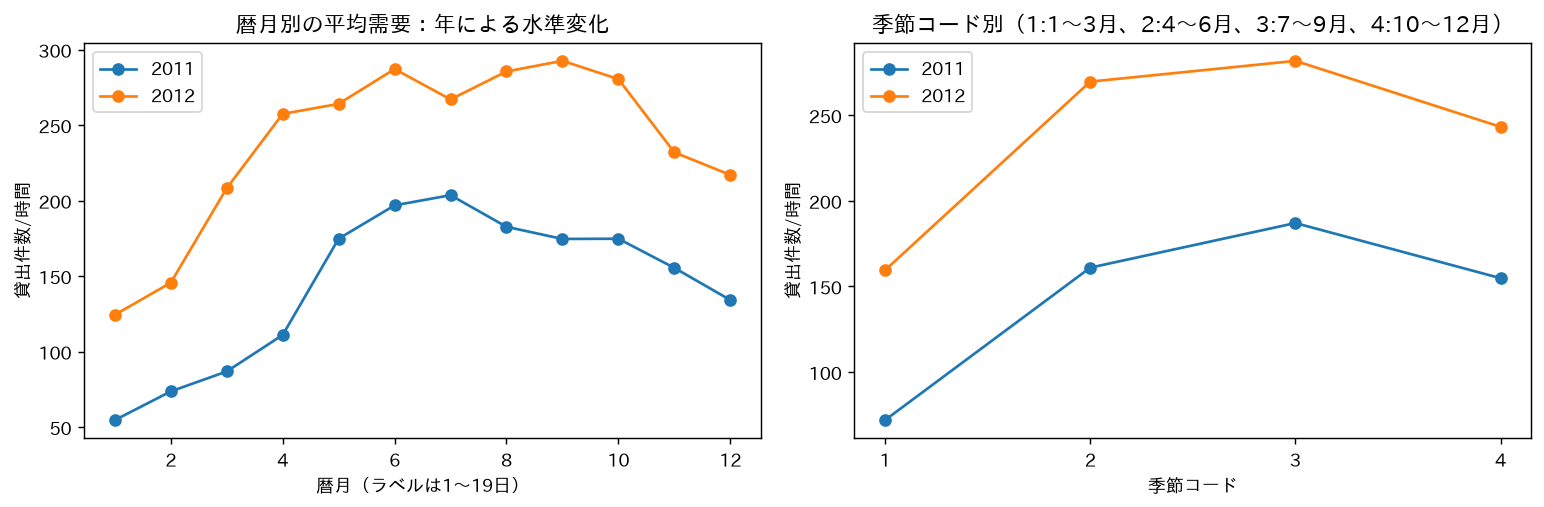

,size,mean,median
weather,,,
1,7192,205.236791,161.0
2,2834,178.955540,134.0
3,859,118.846333,71.0
4,1,164.000000,164.0


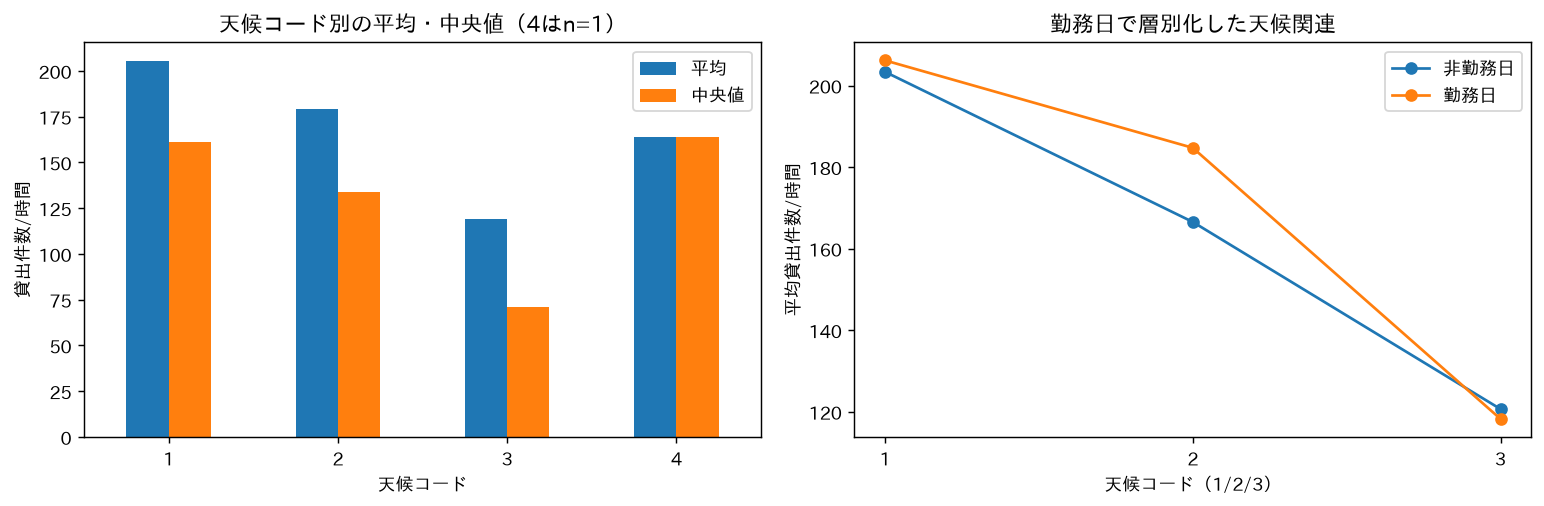

{'初回要約': {'work_8_mean': 479.9451612903226,
  'work_17_mean': 529.2090032154341,
  'nonwork_peak_hour': 13,
  'nonwork_peak_mean': 387.82068965517243,
  'year_growth_ratio': 1.6541076427074761,
  'weather3_vs1_raw_ratio': 0.579069339548848,
  'weather4_n': 1}}

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import japanize_matplotlib
from matplotlib.font_manager import FontProperties, findfont
from matplotlib.ft2font import FT2Font

def emit(fig):
    fig.tight_layout()
    font = FT2Font(findfont(FontProperties(family=plt.rcParams['font.family'])))
    texts = [obj.get_text() for obj in fig.findobj() if hasattr(obj, 'get_text')]
    missing = sorted({ord(char) for text in texts for char in text if not char.isspace() and font.get_char_index(ord(char)) == 0})
    if missing:
        raise ValueError('図表フォントに未対応文字: ' + str(missing))
    buffer = io.BytesIO()
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        fig.savefig(buffer, format='png', dpi=130, bbox_inches='tight')
    glyph_warnings = [str(w.message) for w in captured if 'Glyph' in str(w.message)]
    plt.close(fig)
    if glyph_warnings:
        raise ValueError('欠落グリフ: ' + ';'.join(glyph_warnings))
    output = visualization.build_image_output(buffer.getvalue())
    display(output.data, raw=True)

with phase('初回:分布・時間帯・曜日・季節・天候'):
    display(df['count'].describe(percentiles=[.1,.5,.9,.95,.99]).to_frame())
    png = visualization.render_chart(pd.DataFrame({'log1p_count': np.log1p(df['count'])}), kind='hist', x='log1p_count',
        title='時間別需要の分布（log1p）', xlabel='log(1 + 貸出件数)', ylabel='観測時間数')
    display(visualization.build_image_output(png).data, raw=True)
    hourly = df.groupby(['workingday','hour'])['count'].agg(['size','mean','median']).reset_index()
    display(hourly)
    df['week'] = df.datetime.dt.to_period('W-SUN').astype(str)
    week_ids = sorted(df.week.unique())
    group_ids = pd.MultiIndex.from_product([[0,1],range(24)], names=['workingday','hour'])
    week_sums = df.pivot_table(index='week', columns=['workingday','hour'], values='count', aggfunc='sum').reindex(index=week_ids, columns=group_ids).fillna(0).to_numpy()
    week_n = df.groupby(['week','workingday','hour'])['count'].size().unstack(['workingday','hour']).reindex(index=week_ids, columns=group_ids).fillna(0).to_numpy()
    rng = np.random.default_rng(34)
    weights = rng.multinomial(len(week_ids), np.full(len(week_ids),1/len(week_ids)), size=600)
    bootstrap_means = (weights @ week_sums)/(weights @ week_n)
    ci_low, ci_high = np.quantile(bootstrap_means,[.025,.975],axis=0)
    fig, ax = plt.subplots(figsize=(10,4))
    for work, label in [(0,'非勤務日'),(1,'勤務日')]:
        h = hourly[hourly.workingday==work]
        ax.plot(h.hour,h['mean'], label=label)
        ax.fill_between(range(24),ci_low[work*24:(work+1)*24],ci_high[work*24:(work+1)*24],alpha=.18)
    ax.set(title='時間帯×勤務日：平均と週ブロックbootstrap 95%区間',xlabel='時刻',ylabel='貸出件数/時間')
    ax.set_xticks(range(0,24,2)); ax.legend(); emit(fig)
    weekday = df.pivot_table(index='dow',columns='hour',values='count',aggfunc='mean').reindex(range(7))
    display(df.groupby('dow')['count'].agg(['size','mean','median']))
    fig, ax = plt.subplots(figsize=(11,4))
    image=ax.imshow(weekday,aspect='auto',origin='upper',vmin=0,vmax=550,cmap='viridis')
    ax.set(title='曜日×時刻の平均需要（同一カラースケール）',xlabel='時刻',ylabel='曜日')
    ax.set_yticks(range(7),['月','火','水','木','金','土','日']); ax.set_xticks(range(0,24,2))
    fig.colorbar(image,ax=ax,label='平均貸出件数/時間'); emit(fig)
    monthly = df.groupby('ym')['count'].agg(['size','mean','median'])
    seasonal = df.groupby(['year','season'])['count'].agg(['size','mean','median'])
    display(monthly); display(seasonal)
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    for year in [2011,2012]:
        m = df[df.year==year].groupby('month')['count'].mean()
        axes[0].plot(m.index,m.values,marker='o',label=str(year))
        s = seasonal.loc[year]
        axes[1].plot(s.index,s['mean'],marker='o',label=str(year))
    axes[0].set(title='暦月別の平均需要：年による水準変化',xlabel='暦月（ラベルは1〜19日）',ylabel='貸出件数/時間')
    axes[1].set(title='季節コード別（1:1〜3月、2:4〜6月、3:7〜9月、4:10〜12月）',xlabel='季節コード',ylabel='貸出件数/時間')
    axes[0].legend(); axes[1].legend(); axes[1].set_xticks([1,2,3,4]); emit(fig)
    weather_table = df.groupby('weather')['count'].agg(['size','mean','median'])
    display(weather_table)
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    weather_table[['mean','median']].rename(columns={'mean':'平均','median':'中央値'}).plot.bar(ax=axes[0],rot=0)
    axes[0].set(title='天候コード別の平均・中央値（4はn=1）',xlabel='天候コード',ylabel='貸出件数/時間')
    for work,label in [(0,'非勤務日'),(1,'勤務日')]:
        w = df[(df.workingday==work)&(df.weather<=3)].groupby('weather')['count'].mean()
        axes[1].plot(w.index,w.values,marker='o',label=label)
    axes[1].set(title='勤務日で層別化した天候関連',xlabel='天候コード（1/2/3）',ylabel='平均貸出件数/時間')
    axes[1].set_xticks([1,2,3]); axes[1].legend(); emit(fig)
    initial_summary = {'work_8_mean':float(hourly.query('workingday==1 and hour==8')['mean'].iloc[0]),
        'work_17_mean':float(hourly.query('workingday==1 and hour==17')['mean'].iloc[0]),
        'nonwork_peak_hour':int(hourly[hourly.workingday==0].sort_values('mean').hour.iloc[-1]),
        'nonwork_peak_mean':float(hourly[hourly.workingday==0]['mean'].max()),
        'year_growth_ratio':float(df[df.year==2012]['count'].mean()/df[df.year==2011]['count'].mean()),
        'weather3_vs1_raw_ratio':float(weather_table.loc[3,'mean']/weather_table.loc[1,'mean']),
        'weather4_n':int(weather_table.loc[4,'size'])}
    display({'初回要約': initial_summary})
    print('区間は週単位の標本変動を表す。観測日選択の偏り・未観測年・因果交絡は区間に含まれない。')


未来天候を真値で使う条件付き評価。実際の予報誤差や2013年以降の構造変化は含まない。


,start,end,model,train_n,valid_n,RMSLE,MAE,mean_error,predicted_mean,actual_mean
0,2012-01-01,2012-04-01,hour_workday_mean,5422,1363,0.498849,51.261484,-15.808361,143.668528,159.476889
1,2012-01-01,2012-04-01,poisson,5422,1363,0.453598,40.862911,-25.657316,133.819573,159.476889
2,2012-01-01,2012-04-01,log_squared,5422,1363,0.377503,41.348363,-30.401898,129.074991,159.476889
3,2012-04-01,2012-07-01,hour_workday_mean,6785,1366,0.653850,128.782844,-123.035361,146.566396,269.601757
4,2012-04-01,2012-07-01,poisson,6785,1366,0.329935,43.767242,-20.861488,248.740269,269.601757
5,2012-04-01,2012-07-01,log_squared,6785,1366,0.303835,43.096079,-26.555230,243.046527,269.601757
6,2012-07-01,2012-10-01,hour_workday_mean,8151,1368,0.575383,120.166605,-114.884518,166.850862,281.735380
7,2012-07-01,2012-10-01,poisson,8151,1368,0.313659,44.478470,-17.301708,264.433672,281.735380
8,2012-07-01,2012-10-01,log_squared,8151,1368,0.302618,47.699497,-18.281532,263.453849,281.735380


,model,train_max,test_min,RMSLE,MAE,mean_error,predicted_mean,actual_mean
0,hour_workday_mean,2012-09-19 23:00:00,2012-10-01 00:00:00,0.427275,71.661752,-59.802948,183.386518,243.189466
1,log_squared,2012-09-19 23:00:00,2012-10-01 00:00:00,0.315195,40.023721,-21.589172,221.600294,243.189466


,RMSLE,MAE,mean_error,predicted_mean,actual_mean
ym,,,,,
2012-10,0.302446,49.761442,-30.735123,249.773649,280.508772
2012-11,0.342848,35.260135,-14.910134,217.070086,231.980220
2012-12,0.298439,35.039140,-19.107613,197.947212,217.054825


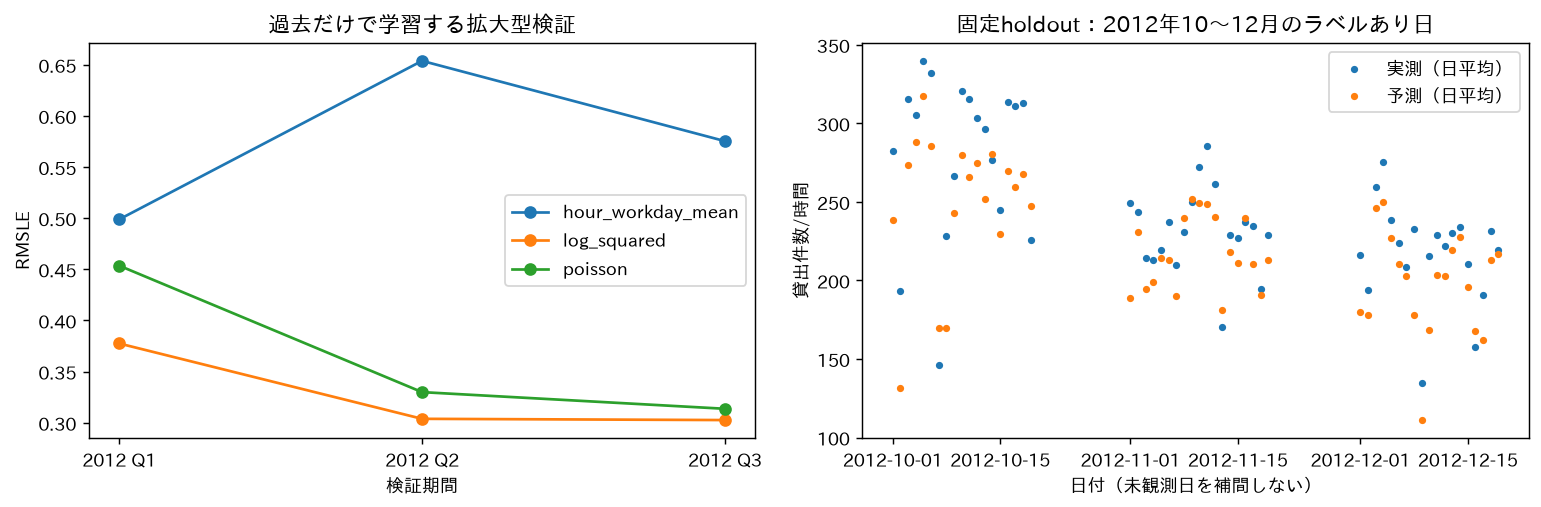

{'時間順検証要約': {'selected_model': 'log_squared',
  'validation_mean_RMSLE': {'log_squared': 0.32798563805075087,
   'poisson': 0.3657305709867495,
   'hour_workday_mean': 0.5760274574473608},
  'holdout_RMSLE': 0.315195102866842,
  'holdout_MAE': 40.02372124349912}}

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_log_error
from threadpoolctl import threadpool_limits
features = ['hour','dow','workingday','holiday','season','month','trend','temp','atemp','humidity','windspeed','weather']
assert not set(features) & {'count','casual','registered'}
categorical = [name in ['hour','dow','workingday','holiday','season','month','weather'] for name in features]

def fit_predict(train, valid, kind):
    if kind == 'hour_workday_mean':
        table = train.groupby(['hour','workingday'])['count'].mean()
        keys = pd.MultiIndex.from_frame(valid[['hour','workingday']])
        prediction = table.reindex(keys)
        if prediction.isna().any():
            raise ValueError('ベースラインに未観測の時間帯×勤務日')
        return prediction.to_numpy()
    model = HistGradientBoostingRegressor(loss='poisson' if kind=='poisson' else 'squared_error',
        max_iter=160, max_leaf_nodes=20, learning_rate=.07, l2_regularization=2,
        min_samples_leaf=30, categorical_features=categorical, early_stopping=False, random_state=34)
    y = train['count'] if kind=='poisson' else np.log1p(train['count'])
    with threadpool_limits(limits=2):
        model.fit(train[features],y)
        p = model.predict(valid[features])
    return np.clip(p if kind=='poisson' else np.expm1(p),0,None)

def metrics(y,p):
    return {'RMSLE':float(np.sqrt(mean_squared_log_error(y,p))), 'MAE':float(mean_absolute_error(y,p)),
        'mean_error':float(np.mean(p-y)), 'predicted_mean':float(np.mean(p)), 'actual_mean':float(np.mean(y))}

with phase('初回:時間順の拡大型検証と固定将来holdout'):
    validation_rows = []
    for start,end in [('2012-01-01','2012-04-01'),('2012-04-01','2012-07-01'),('2012-07-01','2012-10-01')]:
        train = df[df.datetime<pd.Timestamp(start)]
        valid = df[(df.datetime>=pd.Timestamp(start))&(df.datetime<pd.Timestamp(end))]
        assert train.datetime.max() < valid.datetime.min()
        for kind in ['hour_workday_mean','poisson','log_squared']:
            p = fit_predict(train,valid,kind)
            validation_rows.append({'start':start,'end':end,'model':kind,'train_n':len(train),'valid_n':len(valid),**metrics(valid['count'].to_numpy(),p)})
    validation = pd.DataFrame(validation_rows)
    display(validation)
    average_scores = validation.groupby('model').RMSLE.mean().sort_values()
    chosen_kind = average_scores.index[0]
    # モデル選択は2012年9月まで。最終holdoutの指標で設定を変更しない。
    final_train = df[df.datetime<pd.Timestamp('2012-10-01')]
    holdout = df[df.datetime>=pd.Timestamp('2012-10-01')].copy()
    final_predictions = {}
    final_rows = []
    for kind in ['hour_workday_mean',chosen_kind]:
        if kind in final_predictions:
            continue
        p = fit_predict(final_train,holdout,kind)
        final_predictions[kind] = p
        final_rows.append({'model':kind,'train_max':str(final_train.datetime.max()),'test_min':str(holdout.datetime.min()),**metrics(holdout['count'].to_numpy(),p)})
    holdout_scores = pd.DataFrame(final_rows)
    display(holdout_scores)
    holdout['prediction'] = final_predictions[chosen_kind]
    holdout['error'] = holdout.prediction-holdout['count']
    monthly_holdout = holdout.groupby('ym').apply(lambda g: pd.Series(metrics(g['count'].to_numpy(),g.prediction.to_numpy())),include_groups=False)
    display(monthly_holdout)
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    for kind,g in validation.groupby('model'):
        axes[0].plot(range(len(g)),g.RMSLE,marker='o',label=kind)
    axes[0].set_xticks([0,1,2],['2012 Q1','2012 Q2','2012 Q3'])
    axes[0].set(title='過去だけで学習する拡大型検証',xlabel='検証期間',ylabel='RMSLE'); axes[0].legend()
    daily = holdout.groupby('date')[['count','prediction']].mean()
    axes[1].plot(daily.index,daily['count'],'.',label='実測（日平均）')
    axes[1].plot(daily.index,daily.prediction,'.',label='予測（日平均）')
    axes[1].set(title='固定holdout：2012年10〜12月のラベルあり日',xlabel='日付（未観測日を補間しない）',ylabel='貸出件数/時間'); axes[1].legend(); emit(fig)
    display({'時間順検証要約':{'selected_model':chosen_kind,'validation_mean_RMSLE':average_scores.to_dict(),
        'holdout_RMSLE':float(holdout_scores.loc[holdout_scores.model==chosen_kind,'RMSLE'].iloc[0]),
        'holdout_MAE':float(holdout_scores.loc[holdout_scores.model==chosen_kind,'MAE'].iloc[0])}})
    print('未来天候を真値で使う条件付き評価。実際の予報誤差や2013年以降の構造変化は含まない。')


## 反復依頼履歴

### 反復1：原文

> 天候コード3の需要低下が、時間帯・勤務日・月別の成長・気温の構成差によるものか確認してください。週内依存と過分散を考慮した調整後の比と区間を示し、天候4の単一観測、湿度0、風速0の扱い、モデル仕様への感度を検証してください。季節コードは暦月との対応で解釈し、因果効果とは区別してください。

選定理由：初回の天候3/1比は約0.579だが月・時刻・気温が交絡しうる。年水準は約1.65倍で、集計だけでは天候と成長を分離できない。証拠：descriptive、quality。結果と残る限界は次セルおよび最終解釈に記録する。

月固定効果が成長・季節構成を吸収。季節の独立効果は識別していない。NB alphaは固定で、別alpha/Poissonを感度分析。
共変量の実測値に条件付きの観測的関連。週を越えた依存、未観測交絡、天候×時間の効果修飾は残る。
風速0は無風と欠測符号を区別できないため本解析では保持、除外仕様は影響の上限を調べる試験で補正とは呼ばない。


,weather,raw_ratio,adjusted_mean_ratio,cluster95_low,cluster95_high
0,2,0.871947,0.938331,0.912652,0.964733
1,3,0.579069,0.620189,0.569938,0.674872


{'感度分析': {'results': ({'specification': {'family': 'nb1',
     'measurements': 'all'},
    'value': 0.6201894469588348},
   {'specification': {'family': 'nb1', 'measurements': 'positive_only'},
    'value': 0.6431274901031695},
   {'specification': {'family': 'nb05', 'measurements': 'all'},
    'value': 0.6172023589715635},
   {'specification': {'family': 'nb05', 'measurements': 'positive_only'},
    'value': 0.6399262838152012},
   {'specification': {'family': 'poisson', 'measurements': 'all'},
    'value': 0.6275052161133089},
   {'specification': {'family': 'poisson', 'measurements': 'positive_only'},
    'value': 0.6435636892733065}),
  'baseline_value': 0.6201894469588348,
  'stable': True,
  'max_relative_deviation': 0.03768887463192063}}

weather,1,2,3
ym,,,
2011-01,267,138,26
2011-02,312,99,35
2011-03,276,132,38
2011-04,231,166,58
2011-05,267,137,52
2011-06,347,91,18
2011-07,386,56,14
2011-08,334,87,35
2011-09,239,148,66


season,1,2,3,4
year,,,,
2011,71.905518,160.940746,186.994872,154.787125
2012,159.476889,269.601757,281.735380,243.189466


weather,1,2,3
year,,,
2011,154.846218,134.414348,92.082452
2012,255.264339,220.401907,151.642487


{'反復1診断': {'GLM_converged': True,
  'NB_fixed_alpha': 1.0,
  'week_clusters': 87,
  'pearson_scale': 0.12395499386848116,
  'rare_weather4_excluded': 1,
  'positive_measurement_n': 9550,
  'stable': True,
  'max_relative_deviation': 0.03768887463192063}}

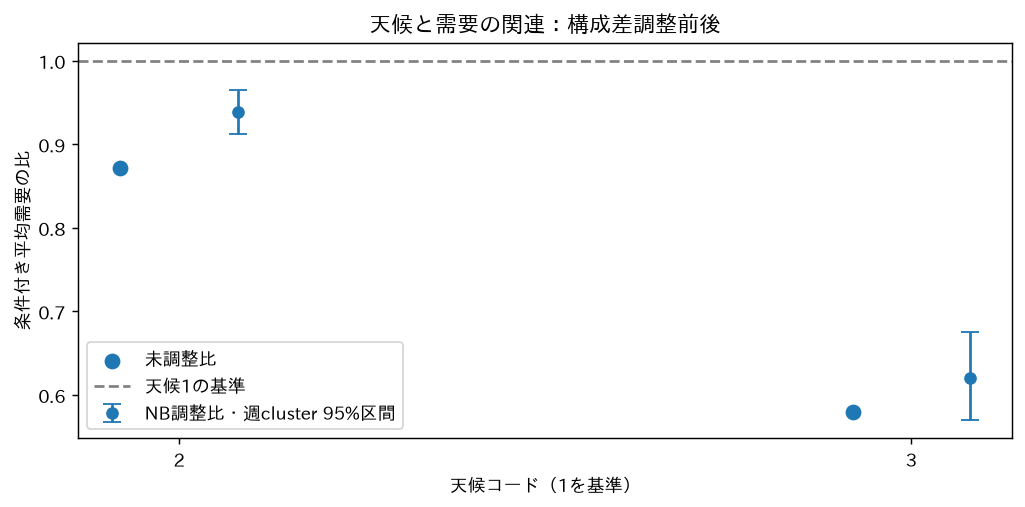

In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import bs

with phase('反復1:天候交絡・分布・感度'):
    adjusted_data = df[df.weather<=3].copy()
    formula = 'count ~ C(weather) + C(hour)*C(workingday) + C(dow) + C(ym) + bs(temp, df=4) + humidity + windspeed'
    model_cache = {}
    def adjusted_ratio(family, measurements):
        data = adjusted_data if measurements=='all' else adjusted_data[(adjusted_data.humidity>0)&(adjusted_data.windspeed>0)]
        fam = sm.families.Poisson() if family=='poisson' else sm.families.NegativeBinomial(alpha=.5 if family=='nb05' else 1)
        with threadpool_limits(limits=2):
            fitted = smf.glm(formula, data=data, family=fam).fit(maxiter=100, cov_type='cluster', cov_kwds={'groups':data.week})
        if not fitted.converged:
            raise RuntimeError('GLMが収束しない')
        model_cache[(family,measurements)] = (fitted,data)
        return float(np.exp(fitted.params['C(weather)[T.3]']))
    plan = sensitivity.SensitivityPlan(parameter_grid={'family':['nb1','nb05','poisson'], 'measurements':['all','positive_only']},max_runs=6)
    sensitivity_weather = sensitivity.run_sensitivity(plan, adjusted_ratio, stability_tolerance=.20)
    fitted,adjusted_sample = model_cache[('nb1','all')]
    weather_adjustment = []
    for code in [2,3]:
        name = f'C(weather)[T.{code}]'
        bounds = np.exp(fitted.conf_int().loc[name].to_numpy())
        weather_adjustment.append({'weather':code,'raw_ratio':float(weather_table.loc[code,'mean']/weather_table.loc[1,'mean']),
            'adjusted_mean_ratio':float(np.exp(fitted.params[name])), 'cluster95_low':float(bounds[0]),'cluster95_high':float(bounds[1])})
    weather_adjustment = pd.DataFrame(weather_adjustment)
    display(weather_adjustment)
    display({'感度分析':asdict(sensitivity_weather)})
    positivity = adjusted_data.groupby(['ym','weather']).size().unstack('weather',fill_value=0)
    display(positivity)
    seasonal_rank = df.groupby(['year','season'])['count'].mean().unstack()
    display(seasonal_rank)
    by_year_weather = df[df.weather<=3].groupby(['year','weather'])['count'].mean().unstack()
    display(by_year_weather)
    diagnostics = {'GLM_converged':bool(fitted.converged),'NB_fixed_alpha':1.0,
        'week_clusters':int(adjusted_sample.week.nunique()), 'pearson_scale':float(np.sum(fitted.resid_pearson**2)/fitted.df_resid),
        'rare_weather4_excluded':1, 'positive_measurement_n':len(model_cache[('nb1','positive_only')][1]),
        'stable':sensitivity_weather.stable,'max_relative_deviation':sensitivity_weather.max_relative_deviation}
    display({'反復1診断':diagnostics})
    fig, ax = plt.subplots(figsize=(8,4))
    ax.scatter(weather_adjustment.weather-.08,weather_adjustment.raw_ratio,label='未調整比',s=60)
    ax.errorbar(weather_adjustment.weather+.08,weather_adjustment.adjusted_mean_ratio,
        yerr=[weather_adjustment.adjusted_mean_ratio-weather_adjustment.cluster95_low,
              weather_adjustment.cluster95_high-weather_adjustment.adjusted_mean_ratio],fmt='o',capsize=5,label='NB調整比・週cluster 95%区間')
    ax.axhline(1,color='gray',linestyle='--',label='天候1の基準')
    ax.set(title='天候と需要の関連：構成差調整前後',xlabel='天候コード（1を基準）',ylabel='条件付き平均需要の比')
    ax.set_xticks([2,3]);ax.legend();emit(fig)
    print('月固定効果が成長・季節構成を吸収。季節の独立効果は識別していない。NB alphaは固定で、別alpha/Poissonを感度分析。')
    print('共変量の実測値に条件付きの観測的関連。週を越えた依存、未観測交絡、天候×時間の効果修飾は残る。')
    print('風速0は無風と欠測符号を区別できないため本解析では保持、除外仕様は影響の上限を調べる試験で補正とは呼ばない。')


### 反復2：原文

> 固定holdoutのRMSLEが良好でも、成長や高需要時間の過小予測を隠していないか診断してください。週ブロックの指標区間とベースラインとの差、勤務日ピーク・高需要層別誤差を示してください。時間帯の結論を年・平均/中央値・祝日除外で感度分析し、毎月20日以降のtest.csvとの共変量分布差から一般化の限界を評価してください。holdoutを見てモデルを再調整しないでください。

選定理由：天候調整比は6仕様で安定した一方、初回holdoutは平均約21.6件/時間の過小予測。需要の右裾と将来移植可能性に関する結論に影響するため、誤差の分解と月末の共変量shiftを検証する。証拠：temporal-validation、iteration-1。

向きは全仕様で1より大きい: True 大きさの安定判定: False 最大相対偏差: 0.2815035118673692
test.csvは同じ期間の月末・ラベルなし。これは共変量shift診断であって独立検証でも需要一致の検証でもない。
反復2は事後的誤差診断であり、Q4の再チューニングは実施していない。区間は約10週の条件付き標本変動のみ。


,dimension,value,n,RMSLE,MAE,mean_error,predicted_mean,actual_mean
0,high_demand,False,1135,0.328958,28.492169,-7.446057,163.650859,171.096916
1,high_demand,True,232,0.236592,96.438856,-90.780705,505.102916,595.883621
2,rush,False,1094,0.329238,30.643207,-11.778729,167.148145,178.926874
3,rush,True,273,0.251164,77.614499,-60.902818,439.807805,500.710623
4,weather,1,778,0.250156,35.683727,-15.265600,249.438771,264.704370
5,weather,2,495,0.341440,38.279393,-23.961590,195.610127,219.571717
6,weather,3,94,0.559400,85.129658,-61.433776,128.055586,189.489362
7,workingday,0,432,0.302823,42.345981,-22.108610,205.632131,227.740741
8,workingday,1,935,0.320750,38.950763,-21.349176,228.978097,250.327273


count  prediction       error
workingday hour                                    
0          0     117.722222   89.797074  -27.925149
           1      97.277778   65.591505  -31.686273
           2      59.111111   53.036604   -6.074507
           3      27.055556   28.651446    1.595891
           4       9.444444    9.666265    0.221820
           5      10.611111   12.451849    1.840738
           6      23.833333   24.582792    0.749458
           7      69.833333   56.691071  -13.142262
           8     165.444444  138.085647  -27.358797
           9     228.277778  225.972775   -2.305002
           10    318.888889  265.744538  -53.144351
           11    405.833333  351.272226  -54.561108
           12    481.888889  415.793960  -66.094929
           13    498.833333  429.918296  -68.915037
           14    481.000000  422.763063  -58.236937
           15    469.833333  421.615860  -48.217474
           16    467.444444  394.008701  -73.435743
           17    393.888889  353.344742  -40.544147
           18    320.000000  308.849514  -11.150486
           19    249.611111  284.079389   34.468278
           20    187.500000  213.777114   26.277114
           21    154.388889  153.261406   -1.127483
           22    127.444444  128.789415    1.344971
           23    100.611111   87.425896  -13.185215
1          0      48.000000   39.525054   -8.474946
           1      19.589744   16.103049   -3.486695
           2      10.128205    8.167944   -1.960261
           3       5.868421    5.418980   -0.449442
           4       8.410256    5.116628   -3.293628
           5      35.846154   29.489011   -6.357143
           6     135.230769  109.770965  -25.459804
           7     384.846154  322.953448  -61.892706
           8     668.615385  551.807584 -116.807801
           9     325.846154  299.582984  -26.263169
           10    173.743590  183.310041    9.566451
           11    208.615385  207.371924   -1.243461
           12    274.435897  262.029063  -12.406834
           13    265.615385  265.617347    0.001963
           14    244.256410  253.564089    9.307679
           15    288.871795  272.455671  -16.416123
           16    408.461538  358.993970  -49.467569
           17    685.820513  607.641332  -78.179181
           18    610.589744  546.242688  -64.347056
           19    420.794872  391.432629  -29.362242
           20    293.256410  274.933326  -18.323084
           21    213.128205  208.407308   -4.720897
           22    160.076923  165.725472    5.648549
           23    111.538462  104.081535   -7.456927

{'反復2誤差区間': {'weeks': 11,
  'bootstrap_runs': 1200,
  'seed': 3402,
  'RMSLE95': [0.2855073913724971, 0.3455536345373609],
  'MAE95': [35.00755923516138, 45.97359299773512],
  'paired_RMSLE_improvement95': [0.06077314076311264, 0.16155531168875278],
  'mean_error': -21.589172368650264,
  'relative_total_bias': -0.08877511318717646,
  'high_demand_threshold_train_q90': 436.0,
  'high_demand_mean_error': -90.78070457408049}}

{'勤務日8時/非勤務日8時の感度': {'results': ({'specification': {'year': 2011,
     'statistic': 'mean',
     'holidays': 'include'},
    'value': 4.308319649095738},
   {'specification': {'year': 2011,
     'statistic': 'mean',
     'holidays': 'exclude'},
    'value': 4.794517065599872},
   {'specification': {'year': 2011,
     'statistic': 'median',
     'holidays': 'include'},
    'value': 5.157894736842105},
   {'specification': {'year': 2011,
     'statistic': 'median',
     'holidays': 'exclude'},
    'value': 5.52112676056338},
   {'specification': {'year': 2012,
     'statistic': 'mean',
     'holidays': 'include'},
    'value': 4.269480955579008},
   {'specification': {'year': 2012,
     'statistic': 'mean',
     'holidays': 'exclude'},
    'value': 4.745647558386412},
   {'specification': {'year': 2012,
     'statistic': 'median',
     'holidays': 'include'},
    'value': 5.046875},
   {'specification': {'year': 2012,
     'statistic': 'median',
     'holidays': 'exclude'},
    'value': 

,variable,early_month_equal_weight_mean,late_month_equal_weight_mean,mean_abs_within_month_shift
0,temp,20.187647,20.459220,2.169180
1,humidity,61.859610,64.014064,5.208544
2,windspeed,12.808185,12.670370,1.522144
3,workingday,0.680776,0.684399,0.075004


,1-19日,20日以降
weather,,
1,0.660548,0.648882
2,0.260470,0.263847
3,0.078890,0.086965
4,0.000092,0.000307


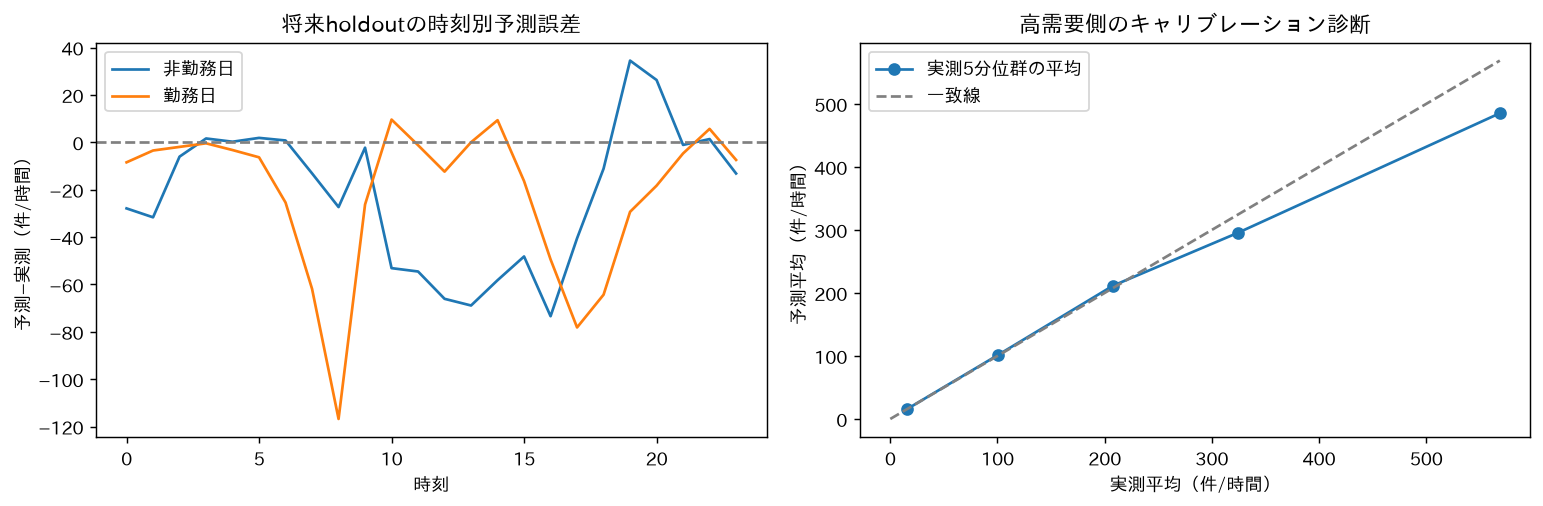

In [9]:
with phase('反復2:高需要・時系列依存・月末分布差'):
    h = holdout.copy()
    h['high_demand'] = h['count'] >= final_train['count'].quantile(.90)
    h['rush'] = (h.workingday==1)&h.hour.isin([7,8,9,16,17,18,19])
    stratified = []
    for group_col in ['high_demand','rush','weather','workingday']:
        for value,g in h.groupby(group_col):
            stratified.append({'dimension':group_col,'value':value,'n':len(g),**metrics(g['count'].to_numpy(),g.prediction.to_numpy())})
    stratified = pd.DataFrame(stratified)
    display(stratified)
    err_by_hour = h.groupby(['workingday','hour'])[['count','prediction','error']].mean()
    display(err_by_hour)
    h['square_log_error'] = (np.log1p(h.prediction)-np.log1p(h['count']))**2
    h['absolute_error'] = abs(h.error)
    baseline_p = final_predictions['hour_workday_mean']
    h['baseline_square_log_error'] = (np.log1p(baseline_p)-np.log1p(h['count']))**2
    week_errors = h.groupby('week')[['square_log_error','absolute_error','baseline_square_log_error']].sum()
    week_counts = h.groupby('week').size().reindex(week_errors.index).to_numpy()
    rng = np.random.default_rng(3402)
    bw = rng.multinomial(len(week_errors),np.full(len(week_errors),1/len(week_errors)),size=1200)
    boot_avg = (bw @ week_errors.to_numpy())/(bw @ week_counts)[:,None]
    boot_rmsle = np.sqrt(boot_avg[:,0])
    boot_improvement = np.sqrt(boot_avg[:,2])-boot_rmsle
    interval_metrics = {'weeks':len(week_errors),'bootstrap_runs':1200,'seed':3402,
        'RMSLE95':np.quantile(boot_rmsle,[.025,.975]).tolist(),
        'MAE95':np.quantile(boot_avg[:,1],[.025,.975]).tolist(),
        'paired_RMSLE_improvement95':np.quantile(boot_improvement,[.025,.975]).tolist(),
        'mean_error':float(h.error.mean()),'relative_total_bias':float(h.prediction.sum()/h['count'].sum()-1),
        'high_demand_threshold_train_q90':float(final_train['count'].quantile(.9)),
        'high_demand_mean_error':float(h[h.high_demand].error.mean())}
    display({'反復2誤差区間':interval_metrics})
    def rush_ratio(year, statistic, holidays):
        sub = df[df.year==year]
        if holidays=='exclude':
            sub = sub[sub.holiday==0]
        table = sub.groupby(['workingday','hour'])['count'].agg(statistic)
        return float(table.loc[(1,8)] / table.loc[(0,8)])
    rush_plan = sensitivity.SensitivityPlan(parameter_grid={'year':[2011,2012], 'statistic':['mean','median'], 'holidays':['include','exclude']},max_runs=8)
    rush_sensitivity = sensitivity.run_sensitivity(rush_plan,rush_ratio,stability_tolerance=.20)
    display({'勤務日8時/非勤務日8時の感度':asdict(rush_sensitivity)})
    print('向きは全仕様で1より大きい:',all(r.value>1 for r in rush_sensitivity.results),
        '大きさの安定判定:',rush_sensitivity.stable,'最大相対偏差:',rush_sensitivity.max_relative_deviation)
    early = df[['datetime','weather','workingday','temp','humidity','windspeed']].copy()
    late = test[['datetime','weather','workingday','temp','humidity','windspeed']].copy()
    for data in [early,late]:
        data['ym'] = data.datetime.dt.to_period('M').astype(str)
    shift_rows = []
    for col in ['temp','humidity','windspeed','workingday']:
        a = early.groupby('ym')[col].mean();b = late.groupby('ym')[col].mean()
        shift_rows.append({'variable':col,'early_month_equal_weight_mean':float(a.mean()),
            'late_month_equal_weight_mean':float(b.mean()),'mean_abs_within_month_shift':float((b-a).abs().mean())})
    display(pd.DataFrame(shift_rows))
    weather_early = early.groupby('ym').weather.value_counts(normalize=True).unstack(fill_value=0).mean()
    weather_late = late.groupby('ym').weather.value_counts(normalize=True).unstack(fill_value=0).mean()
    display(pd.concat([weather_early.rename('1-19日'),weather_late.rename('20日以降')],axis=1))
    print('test.csvは同じ期間の月末・ラベルなし。これは共変量shift診断であって独立検証でも需要一致の検証でもない。')
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    for work,label in [(0,'非勤務日'),(1,'勤務日')]:
        a=err_by_hour.loc[work]
        axes[0].plot(a.index,a.error,label=label)
    axes[0].axhline(0,color='gray',linestyle='--'); axes[0].legend()
    axes[0].set(title='将来holdoutの時刻別予測誤差',xlabel='時刻',ylabel='予測−実測（件/時間）')
    q = pd.qcut(h['count'],5,duplicates='drop')
    calibration = h.groupby(q,observed=True)[['count','prediction']].mean()
    axes[1].plot(calibration['count'],calibration.prediction,'o-',label='実測5分位群の平均')
    lim=float(max(calibration['count'].max(),calibration.prediction.max()))
    axes[1].plot([0,lim],[0,lim],'--',color='gray',label='一致線')
    axes[1].set(title='高需要側のキャリブレーション診断',xlabel='実測平均（件/時間）',ylabel='予測平均（件/時間）'); axes[1].legend(); emit(fig)
    print('反復2は事後的誤差診断であり、Q4の再チューニングは実施していない。区間は約10週の条件付き標本変動のみ。')


### 反復3：原文

> 反復2では天候コード3の将来誤差が他の天候より大きいことが分かりました。全体の天候比を一律に適用しないため、勤務日と非勤務日、6〜19時とそれ以外で天候3の調整比が異なるか、週cluster区間付きで探索してください。各層の観測数を示し、仕様間の差、探索的分析であること、因果・将来一般化の限界を記録してください。

選定理由：反復2の天候3のRMSLEは約0.559（天候1は約0.250）。全体比を各時間帯に一律適用する結論を避けるため、勤務日と時間帯の効果修飾を限定的に調べる。予測モデルの再選択はしない。証拠：iteration-2。

勤務日/昼間のモデルは別々。交互作用を事後に選んだ探索で、多重探索に未調整。各区間の重なりだけで差の有意性を断定しない。
3回の上限に到達。未観測将来年・月末需要・天候4の情報不足は本データで解消できず、これ以上のモデル探索は主結論への価値が小さい。


,modifier,level,weather1_n,weather3_n,ratio_weather3_vs1,cluster95_low,cluster95_high
0,workingday,0,2353,224,0.649821,0.587006,0.719358
1,workingday,1,4839,635,0.609728,0.549981,0.675965
2,daytime,0,3044,343,0.680633,0.616592,0.751326
3,daytime,1,4148,516,0.582205,0.527836,0.642173


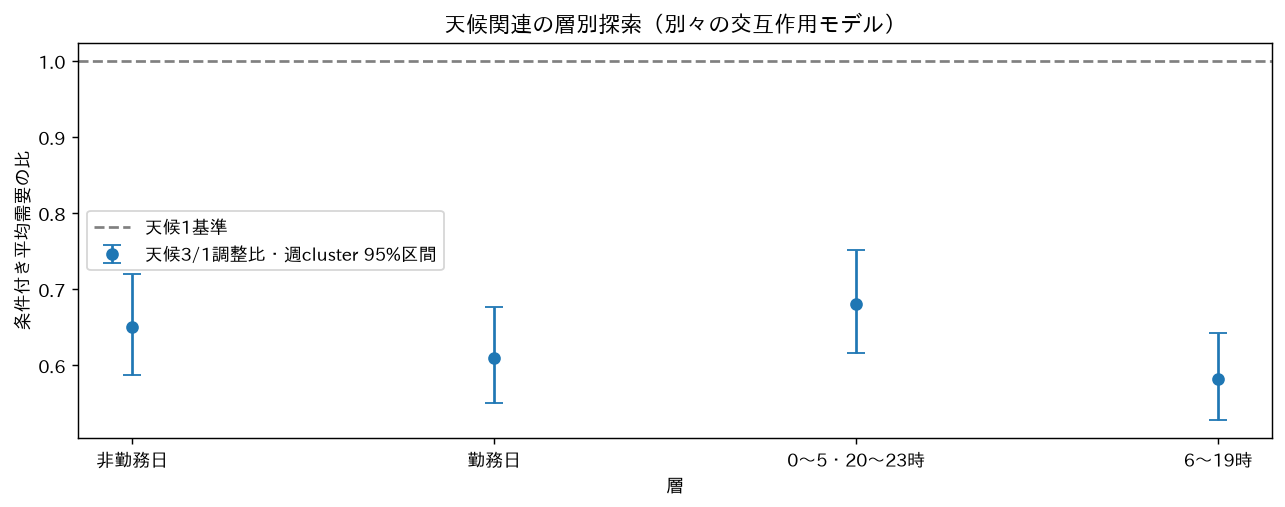

{'反復3要約': {'min_ratio': 0.5822046387844323,
  'max_ratio': 0.6806333722895253,
  'all_ratios_below_1': True}}

In [10]:
with phase('反復3:天候の効果修飾（探索的関連）'):
    interaction_data = adjusted_data.copy()
    interaction_data['w2'] = (interaction_data.weather==2).astype(int)
    interaction_data['w3'] = (interaction_data.weather==3).astype(int)
    interaction_data['daytime'] = interaction_data.hour.between(6,19).astype(int)
    rows = []
    for modifier in ['workingday','daytime']:
        f = formula.replace('C(weather)',f'w2 + w3 + w2:{modifier} + w3:{modifier}',1)
        with threadpool_limits(limits=2):
            result = smf.glm(f, data=interaction_data, family=sm.families.NegativeBinomial(alpha=1)).fit(
                maxiter=100,cov_type='cluster',cov_kwds={'groups':interaction_data.week})
        if not result.converged:
            raise RuntimeError('交互作用GLMが収束しない')
        for level in [0,1]:
            contrast = pd.Series(0.,index=result.params.index)
            contrast['w3'] = 1.
            if level:
                contrast['w3:'+modifier] = 1.
            beta = float(contrast @ result.params)
            se = float(np.sqrt(contrast @ result.cov_params() @ contrast))
            support = interaction_data[interaction_data[modifier]==level].weather.value_counts()
            rows.append({'modifier':modifier,'level':level,'weather1_n':int(support.get(1,0)),
                'weather3_n':int(support.get(3,0)), 'ratio_weather3_vs1':float(np.exp(beta)),
                'cluster95_low':float(np.exp(beta-1.96*se)),'cluster95_high':float(np.exp(beta+1.96*se))})
    interactions = pd.DataFrame(rows)
    display(interactions)
    fig, ax = plt.subplots(figsize=(10,4))
    labels=['非勤務日','勤務日','0〜5・20〜23時','6〜19時']
    ax.errorbar(range(4),interactions.ratio_weather3_vs1,
        yerr=[interactions.ratio_weather3_vs1-interactions.cluster95_low,
              interactions.cluster95_high-interactions.ratio_weather3_vs1],fmt='o',capsize=5,label='天候3/1調整比・週cluster 95%区間')
    ax.axhline(1,color='gray',linestyle='--',label='天候1基準')
    ax.set_xticks(range(4),labels);ax.set(title='天候関連の層別探索（別々の交互作用モデル）',xlabel='層',ylabel='条件付き平均需要の比');ax.legend();emit(fig)
    display({'反復3要約':{'min_ratio':float(interactions.ratio_weather3_vs1.min()),
        'max_ratio':float(interactions.ratio_weather3_vs1.max()),'all_ratios_below_1':bool((interactions.ratio_weather3_vs1<1).all())}})
    print('勤務日/昼間のモデルは別々。交互作用を事後に選んだ探索で、多重探索に未調整。各区間の重なりだけで差の有意性を断定しない。')
    print('3回の上限に到達。未観測将来年・月末需要・天候4の情報不足は本データで解消できず、これ以上のモデル探索は主結論への価値が小さい。')


## 使用したJupytermindモジュール

直接import・呼び出したものだけを記載する。内部からの間接importは計上しない。

| モジュール（ai_data_scientist配下） | 直接呼び出した関数・クラス | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook（初期作成）, ensure_data_dir, enqueue_write | 指定保存先、データ保存、著者書込みの直列化 |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status | 実行・書込み・完了/失敗・協調キャンセル |
| ingestion | SourceSpec, ingest | 取得済みCSVの読み込み、行数制限確認 |
| cleaning | clean_dataset | 重複確認。削除0件、補完なし |
| eda | explore | 型・欠測・要約統計 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | データ定義・出所・未検証項目 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 観測関連・一般化前提と全指摘 |
| data_quality | detect_anomalies | 許容カテゴリ・範囲・一意性・欠測の意味的検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 天候モデル6仕様・時間帯8仕様の安定性 |
| visualization | render_chart, build_image_output | 分布図・PNG MIMEの永続化 |
| insight_engine | extract_cited_value, record_insight, EvidenceMissingError | 実行済み出力の引用と証拠manifest（著者工程）、再現プローブ |
| notebook_audit | audit_notebook(visual_audit=True), _looks_like_insight_candidate（再現診断のみ） | 全コードの実行・エラー・証拠・図表監査 |

**適用不可・未使用**：mcp_gateway.run_and_recordはホスト側のMCPクライアントをNotebookカーネルから呼び戻す構成を利用せず、Jupyter MCP execute_cellで全分析を実行したため直接利用していない。著者書込みはenqueue_write、実行出力はMCP標準保存。record_chartはコードを実行しないので使わず、実際の実行セル内で描画した。stats_analysis.correlationは時系列・カテゴリ交絡を無視する単純相関が主目的に不適切なので未使用。統計z-score外れ値検査は右裾の需要ピークを異常として削除する危険があるため未使用。validate_anomalies/dataset_validation.compare_datasetsは独立ラベル付き参照データがないため適用不可。ML拡張・形式検証・自動データ探索モジュールは利用していない。Kaggle検索はインストール済みSDKを直接使用した。


## Jupytermind改善候補

下記セルで3件の機能不足を再現し、分類・再現条件・期待/実際の挙動・影響・回避策・関連セル/ログを構造化して記録する。ライブラリの契約違反と機能拡張要望を区別する。Kaggle SDK・pandasの分析コード・MCPの起動手順・ベンチマークランナーとは切り分ける。

In [11]:
with phase('Jupytermind改善候補の再現'):
    small_manifest = data_definition.build_manifest(source={},dataset_scope={},variables={'unit':{'definition':data_definition.FieldValue('件/時間','inferred')}})
    inferred_not_returned = len(small_manifest.unresolved_fields())==0
    notebook_snapshot = nbformat.read(handle.notebook_path,as_version=4)
    setup_cell = next(c for c in notebook_snapshot.cells if c.get('id')=='setup')
    stream_present = any('初期化 ja v020-exp-34' in o.get('text','') for o in setup_cell.outputs)
    stream_rejected = False
    if stream_present:
        with phase('証拠プローブの書込み経路',writing=True):
            try:
                insight_engine.record_insight(handle,'# プローブ：stream証拠',setup_cell.execution_count,'初期化 ja v020-exp-34','diagnostic',language='ja')
            except insight_engine.EvidenceMissingError:
                stream_rejected = True
                print('再現ログ：存在するstream出力がEvidenceMissingErrorで拒否された。display出力へ回避。')
    if not stream_rejected:
        raise RuntimeError('stream再現結果が想定と異なるため、改善候補と不要なプローブセルの確認が必要')
    improvements = [
        {'classification':'機能不足（証拠出力型対応）','module':'insight_engine.record_insight',
         'reproduction':'setupセルにstreamとして保存された「初期化 ja v020-exp-34」を実行番号付きで引用する',
         'expected':'実在するstream.textを根拠として検証する', 'actual':'EvidenceMissingError。MIME dataだけを検索する',
         'impact':'printで出した正当な統計量を引用できない', 'workaround':'主結果をdisplay(dict)でtext/plain MIMEに保存しextract_cited_valueで抽出',
         'cells':['setup','library-probes','final-audit'], 'log':'library-probes出力:stream拒否'},
        {'classification':'機能不足（意味的不確実性の列挙）','module':'data_definition.DataDefinitionManifest.unresolved_fields',
         'reproduction':'inferredだけのmanifestにunresolved_fieldsを呼ぶ',
         'expected':'unknownに加え、未検証のinferredを選択的に列挙できる', 'actual':'空リスト。現行docstringはunknownだけであり契約違反ではない',
         'impact':'unknown一覧だけを見ると推定した季節・天候・単位の未検証性を見逃しうる',
         'workaround':'manifestを全件出力しinferredを自前で別途列挙する',
         'cells':['quality','library-probes'], 'log':'library-probes出力:inferred_only_unresolved=0'}]
    display({'再現検査':{'stream_present':stream_present,'stream_rejected':stream_rejected,'inferred_only_unresolved':len(small_manifest.unresolved_fields())}})
    heading_rejected = not notebook_audit._looks_like_insight_candidate('# 結論：証拠付き解釈')
    plain_accepted = notebook_audit._looks_like_insight_candidate('結論：証拠付き解釈')
    display({'見出し監査再現':{'heading_skipped':heading_rejected,'plain_candidate':plain_accepted}})
    improvements.append({'classification':'機能不足（監査対象の検出）','module':'notebook_audit._looks_like_insight_candidate',
        'reproduction':'結論本文が#見出しから始まる場合と見出しを除く場合を比較',
        'expected':'見出しのある結論やevidence fenceを持つセルも証拠監査対象になる',
        'actual':'#始まりは候補から除外。初回最終監査は7証拠セルがあってinsight_cell_count=0',
        'impact':'見出し付き結論の証拠不整合を監査が見逃しうる',
        'workaround':'結論用の固定markdownスロットを使用し本文先頭の#を除去。最終監査対象7件を確認',
        'cells':['library-probes','final-audit'], 'log':'見出し監査再現:heading_skipped=True, plain_candidate=True'})
    display({'Jupytermind改善候補':improvements})
    print('切り分け：Kaggle SDK2.2.4にdataset_viewがない点はdataset_metadataで回避。Jupytermind問題ではない。')
    print('pandas pivot_table(size)の非一意列は分析コードをgroupby.sizeに修正。Notebook新規ディレクトリ不足はMCP起動手順で回避。ベンチマークランナーは起動していない。')

print('MCP固有の切り分けログ：実行中の最終セルを移動すると保存execution_countがNoneに残った。固定位置更新でも自己書込み時には実行出力保存が失われたため、対象Notebookを非実行状態にして外部のMCPセルからenqueue_writeする工程へ分離した。統合箇所の原因は未確定。Jupytermindの不具合とは分類しない。')


再現ログ：存在するstream出力がEvidenceMissingErrorで拒否された。display出力へ回避。
切り分け：Kaggle SDK2.2.4にdataset_viewがない点はdataset_metadataで回避。Jupytermind問題ではない。
pandas pivot_table(size)の非一意列は分析コードをgroupby.sizeに修正。Notebook新規ディレクトリ不足はMCP起動手順で回避。ベンチマークランナーは起動していない。
MCP固有の切り分けログ：実行中の最終セルを移動すると保存execution_countがNoneに残った。固定位置更新でも自己書込み時には実行出力保存が失われたため、対象Notebookを非実行状態にして外部のMCPセルからenqueue_writeする工程へ分離した。統合箇所の原因は未確定。Jupytermindの不具合とは分類しない。


{'再現検査': {'stream_present': True,
  'stream_rejected': True,
  'inferred_only_unresolved': 0}}

{'見出し監査再現': {'heading_skipped': True, 'plain_candidate': True}}

{'Jupytermind改善候補': [{'classification': '機能不足（証拠出力型対応）',
   'module': 'insight_engine.record_insight',
   'reproduction': 'setupセルにstreamとして保存された「初期化 ja v020-exp-34」を実行番号付きで引用する',
   'expected': '実在するstream.textを根拠として検証する',
   'actual': 'EvidenceMissingError。MIME dataだけを検索する',
   'impact': 'printで出した正当な統計量を引用できない',
   'workaround': '主結果をdisplay(dict)でtext/plain MIMEに保存しextract_cited_valueで抽出',
   'cells': ['setup', 'library-probes', 'final-audit'],
   'log': 'library-probes出力:stream拒否'},
  {'classification': '機能不足（意味的不確実性の列挙）',
   'module': 'data_definition.DataDefinitionManifest.unresolved_fields',
   'reproduction': 'inferredだけのmanifestにunresolved_fieldsを呼ぶ',
   'expected': 'unknownに加え、未検証のinferredを選択的に列挙できる',
   'actual': '空リスト。現行docstringはunknownだけであり契約違反ではない',
   'impact': 'unknown一覧だけを見ると推定した季節・天候・単位の未検証性を見逃しうる',
   'workaround': 'manifestを全件出力しinferredを自前で別途列挙する',
   'cells': ['quality', 'library-probes'],
   'log': 'library-probes出力:inferred_only_unresolved=0'},
  {'classificat

## 解釈上の限界と反復の終了判断

**対象の意味**：countは列名・加算恒等式から時間別貸出件数と解釈する。固有の利用者数、潜在需要、満車/在庫切れで失われた需要ではない。公開ミラーの列・件数・期間・SHA-256は検証したが競技オリジナルとのバイト一致は未確認。SDK metadataのdescriptionは空で、天候/季節コードの辞書・摂氏単位・都市・祝日暦は独立検証していない。したがって天候名称や季節名は断定せずコードと暦月で示す。タイムゾーン・風速単位・再配布許諾はunknown。季節は観測上1=1〜3月、2=4〜6月、3=7〜9月、4=10〜12月であり、日本の一般的な春夏秋冬と同一視しない。

**抽出と時系列**：trainは毎月1〜19日だけで、testは20日以降のラベルなし。両者を併せても165時間が欠測し、低需要時間の選択欠測の可能性がある。ゼロ補完はしない。観測された時間の平均を月全体の総需要に換算しない。無作為CVを避けたがQ4検証も毎月前半に限られる。季節と成長は2年しかなく、独立した季節因果効果を識別できない。時間帯の区間は週ブロック、モデル区間は週clusterで依存を扱うが週を越える依存や観測日選択バイアスは残る。

**将来への一般化**：full_month、future_stationarity、weather_forecastの3前提はassumedで、check_manifestの警告を解消したとは扱わない。2012年は2011年より需要水準が高く、木モデルは観測範囲外のtrendを外挿できない。2013年以降・別都市・供給量変更・祝日構造変化に性能保証はない。実測天候を与えた条件付き精度なので気象予報誤差を含む運用精度は別。高需要ピークの容量計画にはRMSLEだけでなくMAE・過小予測を重視する。天候4はn=1で一般化不可。天候比は関連であり「雨がこの割合だけ需要を減らす」という因果解釈はしない。

**反復の結果と終了**：反復1は構成差・測定値・モデル仕様を検証し、天候3の低需要方向は安定。反復2は高需要の過小予測と月末の分布差を明らかにし、朝の勤務日差は方向が安定でも大きさは20%基準を満たさない。反復3は勤務日・時間帯別の天候比を探索し、一律比の適用を避ける。各結果は次の証拠付き結論に示す。3回の上限に到達し、残る核心の不確実性は未観測将来ラベル・月末ラベル・原票定義・独立参照の追加なしでは解消できないため終了した。追加の事後的モデル探索はholdoutの独立性を損ねるため行わない。


## 最終証拠・再実行・監査

著者工程は実行済み出力からextract_cited_valueとrecord_insightで7件の証拠付き結論を作成した。最終セルは実行中Notebookを書き換えず監査する。自分自身は実行中なので除外されるが、MCPの出力保存完了後、外部のMCPセルで12/12実行・7結論の完全監査結果とcompleted状態をmetadataとrun-status.jsonへ記録する。図表9枚を目視確認しvisual_audit=Trueで監査した。

**MCP出力保存完了後の完全監査（実測）**：全12コードセル実行済み、エラー0、未実行0、証拠付き結論7件、PNG9枚、visual_findings=0、findings=0、notebook_audit.ok=True。run_id `v020-exp-34` は `completed`、実行中0・書込み待ち0・保持ロック0。取得CSV2ファイルのSHA-256を再照合した。完全監査の構造化結果と実行/書込みログはNotebook metadata.analysis_runおよびdata/run-status.jsonに保存。


結論：時間帯・曜日

勤務日は8時（約480件/時間）と17時（約529件/時間）にピークがあり、非勤務日は13時（約388件/時間）を中心に昼間へ広がる。曜日の日平均の差だけでなく、曜日×時刻の形を見ることが重要。8時の勤務日/非勤務日比は全8仕様で1を上回るが、最大相対偏差28.15%で大きさの感度安定判定はFalse。

```evidence
{"execution_count":6,"cited_value":"529.2090032154341","claim_type":"descriptive"}
```

結論：季節と成長

1〜3月の季節コード1が最も低く、7〜9月のコード3が最も高い順位は両年で共通。ただし2012年の平均需要は2011年の約1.65倍で、季節集計には成長・気温・供給変化が混在する。日本の春夏秋冬の名称へそのまま置き換えない。

```evidence
{"execution_count":6,"cited_value":"1.6541076427074761","claim_type":"descriptive"}
```

反復1結果：天候関連の調整と感度

天候3/1の未調整比0.579に対し、月・時刻×勤務日・曜日・気温・湿度・風速を調整したNB平均比は0.620（週cluster 95%区間0.570〜0.675）。天候2/1は0.938（0.913〜0.965）。6仕様の天候3比は0.617〜0.644、stable=True、最大相対偏差3.77%。低需要方向は検討した仕様で安定だが因果効果ではない。天候4は1件で推定しない。NBのalpha=1は固定で、分散分布の適合を証明していない。証拠：iteration-1の推定表・感度ログ。残る限界：未観測交絡・週超の依存・天候名称の未検証性。

```evidence
{"execution_count":8,"cited_value":"0.6201894469588348","claim_type":"associational"}
```

結論：時間順の将来期間検証

2012年Q1〜Q3の拡大型検証でlog1p二乗誤差モデルを選び、未調整の固定Q4 holdoutではRMSLE=0.315、MAE=40.0件/時間。時間帯×勤務日平均ベースラインのRMSLE=0.427より改善する。ただし未来天候の真値を使う条件付き性能で、将来年への外挿精度ではない。

```evidence
{"execution_count":7,"cited_value":"0.315195102866842","claim_type":"predictive"}
```

反復2結果：分布の裾と移植限界

holdoutの週ブロック95%区間はRMSLE 0.286〜0.346、MAE 35.0〜46.0、対ベースラインRMSLE改善0.061〜0.162。全体需要を約8.88%過小予測し、学習期間の90%点436件以上では平均約90.8件/時間過小。勤務日8時の平均誤差は約−116.8件/時間で、RMSLEが小さくても容量計画に十分とはいえない。月末testとの月内平均差は気温約2.17（単位未検証）、湿度約5.21（単位未検証）で、ラベルがないため月末需要の一致を検証できない。証拠：iteration-2の層別表・区間・分布shift。残る限界：11週だけの条件付き区間、観測外ピーク・将来変化。

```evidence
{"execution_count":9,"cited_value":"-0.08877511318717646","claim_type":"predictive"}
```

反復3結果：一律の天候比を避ける

天候3/1の調整比は非勤務日0.650（0.587〜0.719）、勤務日0.610（0.550〜0.676）。別モデルで6〜19時は0.582（0.528〜0.642）、それ以外は0.681（0.617〜0.751）。低需要方向は各層で共通だが、同じ比を全時間に当てはめない。証拠：iteration-3の各層nと週cluster区間。残る限界：事後的探索・多重探索未調整・別々の交互作用モデルであり、層間差の確定的検定や因果推定ではない。

```evidence
{"execution_count":10,"cited_value":"0.5822046387844323","claim_type":"associational"}
```

感度判定の読み方

朝の勤務日差は8仕様で方向が共通でも、勤務日8時/非勤務日8時比の最大相対偏差は約28.15%でstable=False。これを「全仕様で完全に頑健」とは表現しない。天候比のstable=Trueも検討した6仕様・20%許容範囲に限定される。

```evidence
{"execution_count":9,"cited_value":"0.2815035118673692","claim_type":"associational"}
```

In [12]:
import importlib.metadata
with phase('最終監査:実行中Notebookへの書込みを行わない'):
    report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not report.ok or report.insight_cell_count != 7 or report.visual_findings:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Notebook/図表/7結論の証拠監査が失敗')
    artifacts = {'provenance':provenance,'data_definition':asdict(definition),'analysis_assumptions':asdict(assumptions),
        'assumption_findings':[asdict(f) for f in assumption_findings],'semantic_quality':quality_summary,
        'weather_sensitivity':asdict(sensitivity_weather),'rush_sensitivity':asdict(rush_sensitivity),'improvements':improvements,
        'versions':{name:importlib.metadata.version(name) for name in ['pandas','numpy','matplotlib','scikit-learn','statsmodels','kaggle','nbformat']}}
    with phase('manifestファイル保存',writing=True):
        for name,value in artifacts.items():
            (DATA_DIR / (name+'.json')).write_text(json.dumps(value,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
lifecycle.mark_completed(RUN_ID)
status = lifecycle.get_run_status(RUN_ID)
with phase('完了状態ファイル保存',writing=True):
    payload = {'audit':{**asdict(report),'ok':report.ok},'lifecycle':asdict(status),'phase_log':phase_log}
    (DATA_DIR / 'run-status.json').write_text(json.dumps(payload,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
display({'notebook_audit':{**asdict(report),'ok':report.ok}})
display({'lifecycle':asdict(lifecycle.get_run_status(RUN_ID))})
print('カーネル再起動後に全12コードセルを上から再実行。最終セルの出力保存後、外部のJupyter MCPセルから完全監査結果と完了metadataをenqueue_writeで記録する。')
print('図表5セル・PNG計9枚、7結論の証拠を監査。未実行の末尾セル除外は自分自身のみ。')


カーネル再起動後に全12コードセルを上から再実行。最終セルの出力保存後、外部のJupyter MCPセルから完全監査結果と完了metadataをenqueue_writeで記録する。
図表5セル・PNG計9枚、7結論の証拠を監査。未実行の末尾セル除外は自分自身のみ。


{'notebook_audit': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-34-bike-sharing/notebooks/kaggle-v020-kaggle-exp-34-bike-sharing.ipynb',
  'nbformat_valid': True,
  'code_cell_count': 12,
  'executed_code_cell_count': 11,
  'unexecuted_cell_indices': (),
  'error_cell_indices': (),
  'chart_cell_indices': (8, 9, 11, 13, 15),
  'insight_cell_count': 7,
  'findings': ({'severity': 'warning',
    'message': 'Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.',
    'cell_index': 28},),
  'visual_findings': (),
  'ok': True}}

{'lifecycle': {'run_id': 'v020-exp-34',
  'state': 'completed',
  'active_cell_executions': 0,
  'pending_notebook_writes': 0,
  'locks_held': 0,
  'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-34-bike-sharing/notebooks/kaggle-v020-kaggle-exp-34-bike-sharing.ipynb',
  'reason': None}}